In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [ ]:
import tensorflow as tf
import os

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

if tf.test.is_gpu_available():
    print("GPU is available.")
    print("GPU Device Name:", tf.test.gpu_device_name())
else:
    print("No GPU available, TensorFlow will run on CPU.")

# You can also run a shell command to see GPU status
!nvidia-smi

TensorFlow Version: 2.20.0
Num GPUs Available:  1
GPU is available.
GPU Device Name: /device:GPU:0
Sat May 30 01:52:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P0             31W /   70W |    2171MiB /  15360MiB |      0%      Default |
|                                        

In [ ]:
dataset_path = '/root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1'

# List the contents of the downloaded dataset path
print(f"Contents of {dataset_path}:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

# Assuming a common structure like 'training_set' and 'test_set' inside the main dataset folder
# We will use this to define our base paths for image loading.
base_data_dir = os.path.join(dataset_path, 'cat-and-dog') # Adjust based on actual inspection

Contents of /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1:


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Define data directories using the correct 'path' variable from kagglehub download
# Adjusted paths to account for nested directory structure (e.g., training_set/training_set/)
train_dir = os.path.join(path, 'training_set', 'training_set')
validation_dir = os.path.join(path, 'test_set', 'test_set') # Assuming 'test_set' is used for validation

# Check if directories exist
if not os.path.exists(train_dir):
    print(f"Training directory not found: {train_dir}")
if not os.path.exists(validation_dir):
    print(f"Validation directory not found: {validation_dir}")

# Data augmentation and preprocessing for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Data preprocessing for validation (only rescale)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches from directory 'train_dir'
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# Flow validation images in batches from directory 'validation_dir'
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load MobileNetV2 pre-trained on ImageNet without the top classification layer
base_model = MobileNetV2(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
                         include_top=False,
                         weights='imagenet')

# Unfreeze all layers of the base model for fine-tuning
base_model.trainable = True

# Freeze layers until a certain point to retain low-level features
# A common practice is to freeze the initial layers and unfreeze the top ones.
# Let's unfreeze the last few convolutional blocks for fine-tuning.
# We can determine this by inspecting `base_model.layers`.
# For MobileNetV2, 'block_13_expand' is often a good point to start unfreezing.

for layer in base_model.layers:
    if not layer.name.startswith('block_13'): # Freeze layers up to block_13
        layer.trainable = False
    else:
        layer.trainable = True

# Add custom classification layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Global Average Pooling layer
x = Dense(128, activation='relu')(x) # A dense layer with 128 units and ReLU activation
x = Dropout(0.5)(x) # Add a Dropout layer for regularization
predictions = Dense(1, activation='sigmoid')(x) # Output layer for binary classification

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model with a lower learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=0.00001), # Reduced learning rate for fine-tuning
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display model summary
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 319,361 (1.22 MB)

 Non-trainable params: 2,102,720 (8.02 MB)

In [ ]:
EPOCHS = 20 #You can increase this for better performance

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 134s 487ms/step - accuracy: 0.6535 - loss: 0.6401 - val_accuracy: 0.8725 - val_loss: 0.4364
Epoch 2/20
  1/250 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.6562 - loss: 0.6033

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6562 - loss: 0.6033 - val_accuracy: 0.8730 - val_loss: 0.4351
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 111s 444ms/step - accuracy: 0.8437 - loss: 0.3770 - val_accuracy: 0.9187 - val_loss: 0.2759
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8750 - loss: 0.3422 - val_accuracy: 0.9187 - val_loss: 0.2755
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 112s 446ms/step - accuracy: 0.8997 - loss: 0.2708 - val_accuracy: 0.9464 - val_loss: 0.1882
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.9062 - loss: 0.1713 - val_accuracy: 0.9459 - val_loss: 0.1889
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 433ms/step - accuracy: 0.9251 - loss: 0.2017 - val_accuracy: 0.9653 - val_loss: 0.1351
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9375 - loss: 0.2210 - val_accuracy: 0.9648 - val_loss: 0.1363
Epoch 9/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 111s 442ms/step - accuracy: 0.9372 - loss: 0.1672 - val_ac

In [ ]:
print("\n--- Training Summary ---")
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")


--- Training Summary ---
Final Training Accuracy: 0.8438
Final Validation Accuracy: 0.9841
Final Training Loss: 0.2404
Final Validation Loss: 0.0533


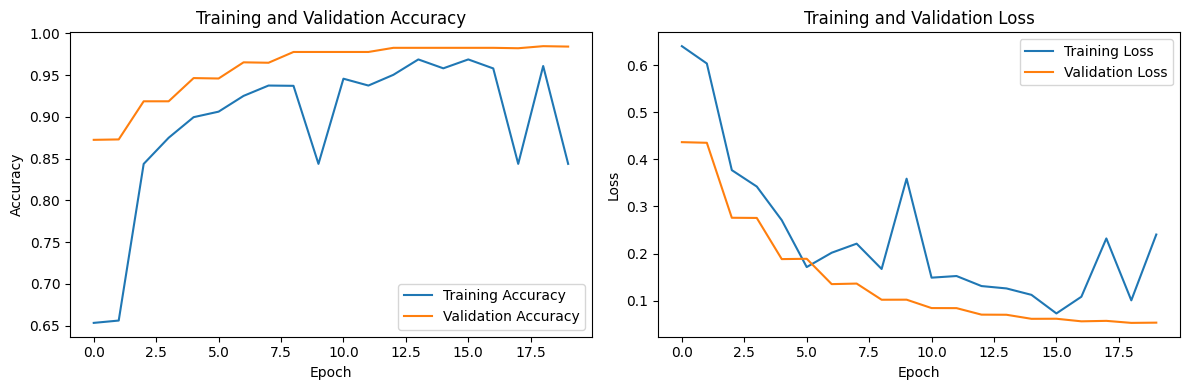

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import os

print(f"Contents of training directory ({train_dir}):")
# List immediate subdirectories and files in train_dir
for item in os.listdir(train_dir):
    full_path = os.path.join(train_dir, item)
    if os.path.isdir(full_path):
        print(f"  [DIR] {item}/")
    else:
        print(f"  [FILE] {item}")

print(f"\nContents of validation directory ({validation_dir}):")
# List immediate subdirectories and files in validation_dir
for item in os.listdir(validation_dir):
    full_path = os.path.join(validation_dir, item)
    if os.path.isdir(full_path):
        print(f"  [DIR] {item}/")
    else:
        print(f"  [FILE] {item}")


Contents of training directory (/kaggle/input/cat-and-dog/training_set/training_set):
  [DIR] dogs/
  [DIR] cats/

Contents of validation directory (/kaggle/input/cat-and-dog/test_set/test_set):
  [DIR] dogs/
  [DIR] cats/
